# Pension model - Data exploration

1. Data Import & Preliminary Analysis

2. Exploratory Data Analysis (EDA) & Relationship Checks

3. Feature Engineering & Preprocessing

4. Model Selection & Baseline Modeling (GLR, others)

5. Model Diagnostics & Convergence Monitoring

6. Overfitting Avoidance & Regularization

7. Model Evaluation & Testing

---

In [12]:
import numpy as np
import pandas as pd

import plotly.express as px

## Data import and preliminar analysis

In [3]:
dtypes = {
    "Annee": "int64",
    "D_PIB": "float64"
}

raw_df = pd.read_csv("../data/dataset_COR_norm.csv", index_col=False, dtype=dtypes)
raw_df = raw_df.loc[:, ~raw_df.columns.str.contains("^Unnamed")]

In [4]:
raw_df.head()

,Annee,D_PIB,PROD,CHO,MI,FEC,ESP_F,ESP_H,PIB_VAL,PRELEV_REF,CONTRIB_REF,PIB_VOL
0,2002,0.117761,0.02786,0.079,97000,1.881,21.4,17.1,1578.330,26.9,2.0,2003.664
1,2003,0.118774,0.00614,0.085,102000,1.891,21.3,17.1,1622.313,27.6,2.0,2023.056
2,2004,0.119571,0.01315,0.089,105128,1.915,22.1,17.7,1696.108,27.9,2.0,2081.082
3,2005,0.121331,0.00955,0.089,92192,1.938,22.0,17.7,1762.048,27.9,2.0,2120.384
4,2006,0.121535,0.02648,0.088,112141,1.997,22.4,18.0,1846.021,28.0,2.1,2177.933


## Retail real data, i.e., data related only to past periods

In [16]:
df = raw_df[raw_df['Annee'] < 2025]
df = raw_df.copy()

In [17]:
# Summary statistics
df.describe()

,Annee,D_PIB,PROD,CHO,MI,FEC,ESP_F,ESP_H,PIB_VAL,PRELEV_REF,CONTRIB_REF,PIB_VOL
count,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000
mean,2036.000000,0.134491,0.008177,0.063207,81079.521739,1.838652,24.343853,21.143610,4685.602014,29.746377,1.633333,2991.050815
std,19.934557,0.006250,0.006614,0.018460,42234.172405,0.074955,1.555165,2.261439,2465.326359,1.213904,0.383949,602.376366
min,2002.000000,0.117761,-0.016730,0.050000,20000.000000,1.676000,21.300000,17.100000,1578.330000,26.900000,1.000000,2003.664000
25%,2019.000000,0.131858,0.005990,0.050000,70000.000000,1.800000,23.200000,19.300000,2355.363000,28.800000,1.200000,2454.866000
50%,2036.000000,0.136132,0.010000,0.050000,70000.000000,1.800000,24.101975,20.915120,4213.431000,29.500000,1.700000,3022.141500
75%,2053.000000,0.138264,0.010000,0.079000,97000.000000,1.863000,25.400680,22.883942,6449.581750,30.700000,2.000000,3430.971000
max,2070.000000,0.148541,0.027860,0.103000,223005.000000,2.029000,29.734260,27.653890,11438.130000,32.200000,2.100000,4569.054000


In [18]:
# Check for missing values
df.isnull().sum()

Annee          0
D_PIB          0
PROD           0
CHO            0
MI             0
FEC            0
ESP_F          0
ESP_H          0
PIB_VAL        0
PRELEV_REF     0
CONTRIB_REF    0
PIB_VOL        0
dtype: int64

## Exploratory data analysis

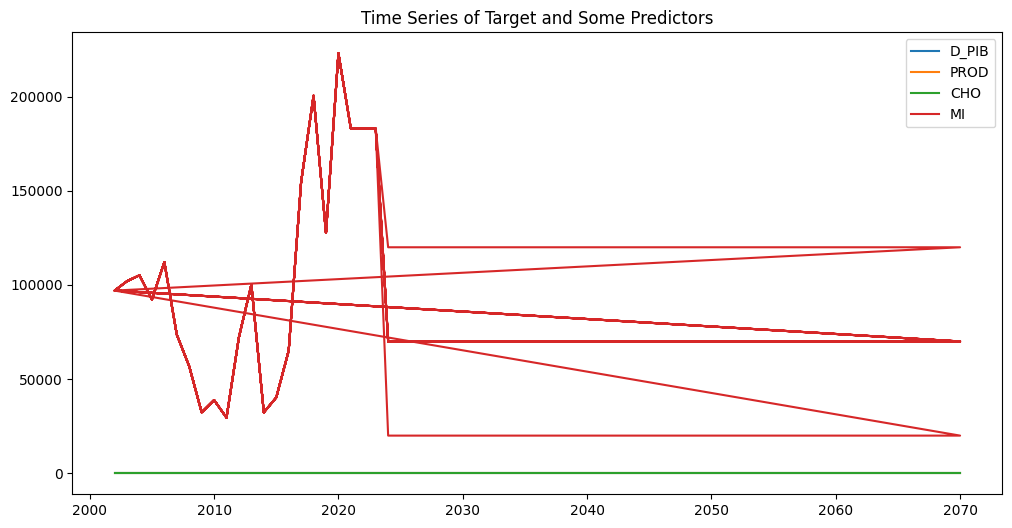

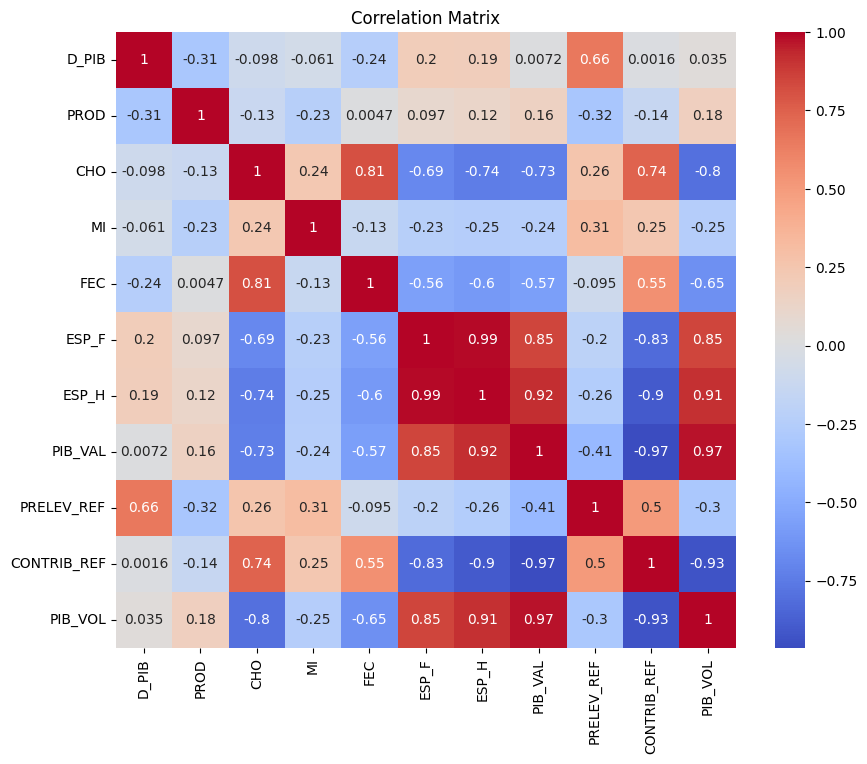

ADF Statistic: -4.080343197573702
p-value: 0.0010435758670899258
Time series is stationary.


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot target and some predictors over time
plt.figure(figsize=(12,6))
plt.plot(df['Annee'], df['D_PIB'], label='D_PIB')
for col in ['PROD', 'CHO', 'MI']:
    plt.plot(df['Annee'], df[col], label=col)
plt.legend()
plt.title('Time Series of Target and Some Predictors')
plt.show()

# Correlation matrix heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns='Annee').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Check stationarity (ADF test)
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['D_PIB'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
if result[1] > 0.05:
    print("Time series is non-stationary; consider differencing.")
else:
    print("Time series is stationary.")

In [20]:
df

,Annee,D_PIB,PROD,CHO,MI,FEC,ESP_F,ESP_H,PIB_VAL,PRELEV_REF,CONTRIB_REF,PIB_VOL
0,2002,0.117761,0.02786,0.079,97000,1.881,21.40000,17.10000,1578.330,26.9,2.0,2003.664
1,2003,0.118774,0.00614,0.085,102000,1.891,21.30000,17.10000,1622.313,27.6,2.0,2023.056
2,2004,0.119571,0.01315,0.089,105128,1.915,22.10000,17.70000,1696.108,27.9,2.0,2081.082
3,2005,0.121331,0.00955,0.089,92192,1.938,22.00000,17.70000,1762.048,27.9,2.0,2120.384
4,2006,0.121535,0.02648,0.088,112141,1.997,22.40000,18.00000,1846.021,28.0,2.1,2177.933
...,...,...,...,...,...,...,...,...,...,...,...,...
547,2066,0.131398,0.01000,0.050,70000,1.800,23.99277,21.93565,9250.220,28.7,1.1,3960.600
548,2067,0.131499,0.01000,0.050,70000,1.800,24.02340,22.00315,9492.102,28.7,1.0,3994.265
549,2068,0.131601,0.01000,0.050,70000,1.800,24.05405,22.07035,9740.309,28.7,1.0,4028.216
550,2069,0.131750,0.01000,0.050,70000,1.800,24.08470,22.13728,9993.023,28.7,1.0,4061.651


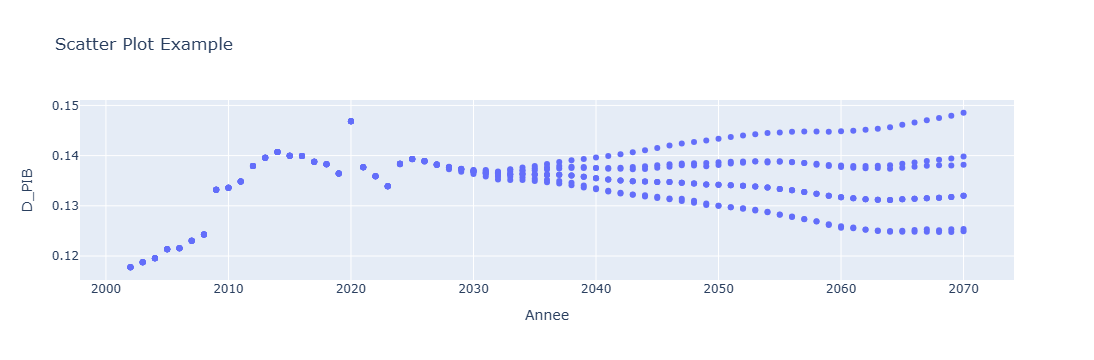

In [21]:
# Scatter plot
fig = px.scatter(
    df,
    x=df['Annee'],
    y=df['D_PIB'],
    #text='label',  # Optional: display labels on points
    title='Scatter Plot Example'
)

fig.show()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# First scatter
fig.add_trace(go.Scatter(
    x=df['Annee'],
    y=df['D_PIB'],
    mode='markers',
    name='D_PIB'
))

# Add another scatter trace
fig.add_trace(go.Scatter(
    x=df['Annee'],
    y=df['Another_Column'],
    mode='markers',
    name='Another_Column'
))

# Optional: Add more columns
# fig.add_trace(go.Scatter(...))

fig.update_layout(title='Scatter Plot with Multiple Columns')
fig.show()